In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

pc1 [[[169.3728, 188.57601928710938], [252.42786, 190.3455047607422]], [[464.21503, 129.82461547851562], [552.4784, 132.55868530273438]], [[466.26123, 14.039850234985352], [550.9252, 14.273862838745117]], [[83.79451, 122.55018615722656], [169.09317, 125.2747802734375]], [[57.832294, 250.08477783203125], [147.69473, 253.75299072265625]], [[286.33493, 12.397476196289062], [370.12396, 14.1732759475708]], [[459.2906, 259.0635070800781], [553.36365, 260.76324462890625]], [[198.27635, 11.794517517089844], [276.76797, 12.397476196289062]], [[146.70316, 325.66729736328125], [236.11783, 326.725341796875]], [[108.24648, 10.019006729125977], [187.57292, 11.794517517089844]], [[354.13147, 329.0121154785156], [447.09607, 331.7273864746094]], [[158.17374, 253.75299072265625], [245.30666, 256.0281982421875]], [[380.66217, 14.1732759475708], [456.74707, 14.039850234985352]], [[264.14423, 190.3455047607422], [355.33463, 192.39492797851562]], [[464.72296, 67.82476806640625], [550.50757, 69.0775604248046

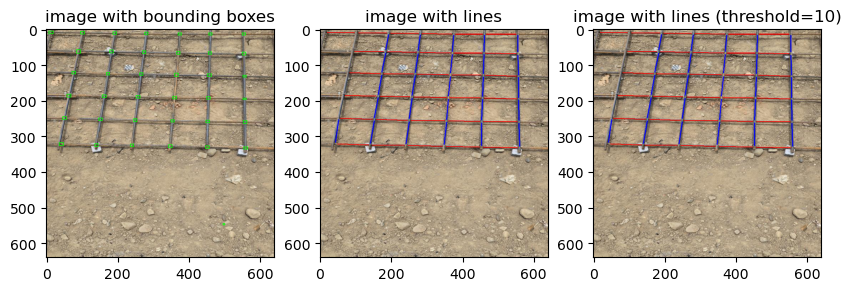

pc1 [[[96.95217, 59.518707275390625], [149.7599, 60.86376190185547]], [[23.827272, 107.846435546875], [80.5295, 109.15777587890625]], [[400.7054, 116.96536254882812], [444.7051, 94.11585998535156]], [[507.97095, 279.5377197265625], [567.10144, 279.34564208984375]], [[88.20905, 109.15777587890625], [142.3228, 137.6102294921875]], [[389.9745, 67.84098815917969], [437.65802, 69.20944213867188]], [[350.92184, 173.01046752929688], [404.93042, 173.34019470214844]], [[341.7802, 115.63496398925781], [392.67526, 116.96536254882812]], [[66.947876, 237.92718505859375], [131.00574, 238.64608764648438]], [[379.63593, 24.706249237060547], [415.58002, 5.9510817527771]], [[219.19717, 39.872161865234375], [266.66263, 20.983173370361328]], [[43.975475, 364.7178955078125], [119.51227, 363.69940185546875]], [[49.906586, 12.676599502563477], [97.33733, 14.425504684448242]], [[303.4926, 525.71044921875], [387.9115, 525.02783203125]], [[93.134285, 84.09901428222656], [147.13638, 86.3946533203125]], [[214.627

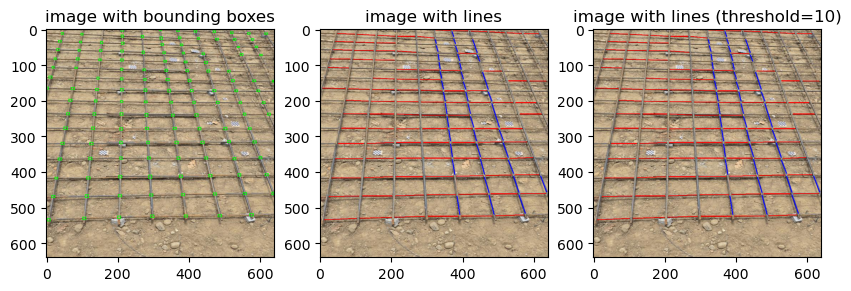

pc1 [[[118.241165, 245.16542053222656], [178.28217, 223.68939208984375]], [[410.1239, 510.38592529296875], [471.3886, 474.9046630859375]], [[478.47562, 135.32424926757812], [519.3259, 120.39618682861328]], [[427.16953, 151.03314208984375], [470.2374, 135.32424926757812]], [[502.62878, 189.16207885742188], [546.05664, 171.56260681152344]], [[254.24396, 203.122314453125], [306.6413, 184.59799194335938]], [[391.76617, 229.95533752441406], [441.62173, 207.2115478515625]], [[315.46198, 184.59799194335938], [362.06082, 168.38607788085938]], [[126.31555, 322.1551208496094], [193.51904, 306.8424072265625]], [[159.59808, 625.2357177734375], [244.69958, 580.2684326171875]], [[310.27258, 435.8553466796875], [369.56143, 405.802978515625]], [[449.2565, 207.2115478515625], [495.08057, 189.16207885742188]], [[479.1391, 474.9046630859375], [536.9411, 443.2438659667969]], [[55.375084, 542.7247314453125], [137.67453, 508.06982421875]], [[553.37317, 171.56260681152344], [595.6331, 152.68319702148438]], [

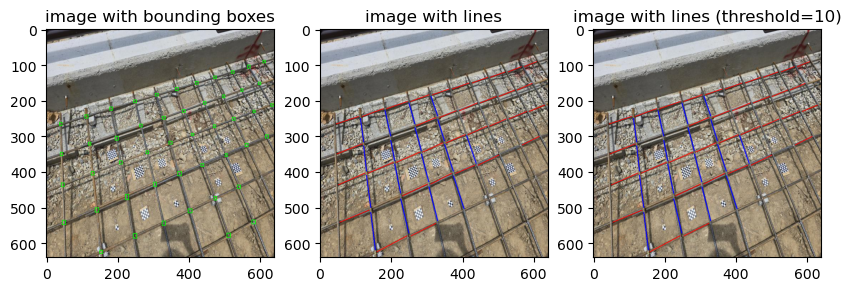

In [2]:
image_paths = [
    "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg",
    "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg",
    "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg",
]
model_path = "runs/detect/tune/weights/best.pt"


# Draw bounding boxes
def draw_bounding_boxes(image_path, model_path):
    image = Image.open(image_path)
    draw_boxes = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image, model_path)
    for box in bounding_boxes:
        draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=2)

    return image


# Draw lines
def draw_lines(image_path, model_path, threshold=10):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image_path, model_path, threshold=threshold)
    data = json.loads(json_data)
    for shape in data["shapes"]:
        points = shape["points"]
        color = "red" if shape["orientation"] == "horizontal" else "blue"
        draw_lines.line([tuple(points[0]), tuple(points[1])], fill=color, width=3)

    return image


def show_result(image_path, model_path):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("image with bounding boxes")
    plt.imshow(draw_bounding_boxes(image_path, model_path))
    plt.subplot(1, 3, 2)
    plt.title("image with lines")
    plt.imshow(draw_lines(image_path, model_path, threshold=0))
    plt.subplot(1, 3, 3)
    plt.title("image with lines (threshold=10)")
    plt.imshow(draw_lines(image_path, model_path))
    plt.show()


for path in image_paths:
    show_result(path, model_path)
